In [11]:
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")


In [14]:
# pip install langgraph

from typing import TypedDict

class SimpleState(TypedDict):
    input_text: str
    output_text: str


In [ ]:
# SimpleState = {
#     "input_text": "Hello, how are you?",
#     "output_text": "I'm fine, thank you!"
# }


In [12]:
def process_input(state: SimpleState) -> SimpleState:
    # Simulate some processing on the input_text
    state["output_text"] = llm.invoke(state["input_text"]).content
    return state


In [15]:
state = SimpleState(input_text="Hello, how are you?",
                     output_text="")

In [16]:
process_input(state)

{'input_text': 'Hello, how are you?',
 'output_text': "Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"}

In [17]:
state

{'input_text': 'Hello, how are you?',
 'output_text': "Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"}

In [26]:
def process_input(state: SimpleState) -> SimpleState:
    # Simulate some processing on the input_text
    state["output_text"] = llm.invoke(state["input_text"]).content
    return state


def add_prefix(state: SimpleState) -> SimpleState:
    state["input_text"] = "User: " + state["output_text"]
    return state

def add_suffix(state: SimpleState) -> SimpleState:
    state["output_text"] = llm.invoke(state["input_text"] + " Please provide a response.").content
    return state


In [28]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SimpleState)
builder.add_node("process_input", process_input)
builder.add_node("add_prefix", add_prefix)
builder.add_node("add_suffix", add_suffix)

builder.add_edge(START, "process_input")
builder.add_edge("process_input", "add_prefix")
builder.add_edge("add_prefix", "add_suffix")
builder.add_edge("add_suffix", END)

graph = builder.compile()


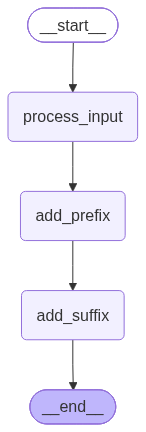

In [29]:
graph

In [30]:
initial_state = {
    "input_text": "Hello, how can I help you?",
    "output_text": ""
}

graph.invoke(initial_state)

{'input_text': "User: Hello! I'm here to assist you with any questions or topics you'd like to discuss. How can I help you today?",
 'output_text': "Hello! Thank you for your offer to help. I have a few questions about a topic I'm interested in. Can we discuss the impact of climate change on global ecosystems?"}

In [ ]:
# add_prefix(state)

{'input_text': "User: Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?",
 'output_text': "Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"}